# MetaAlgorithmGA Testing Notebook

This notebook demonstrates how to use the MetaAlgorithmGA to optimize matching on graphs, including large 1K-node graphs.

## Setup & Imports

In [6]:
import sys

from meta.core import CanonicalVector, FitnessEvaluator, MetaAlgorithmGA
from monitoring import run_ga_experiment_monitored

sys.path.insert(0, '..')

from src.graph.graph_manager import GraphManager
from tests.fixtures.graphs import (_create_clustered_graph,
    CLUSTERED_GRAPH_1K, RANDOM_DENSE_GRAPH_1K, SCALE_FREE_GRAPH_1K,
    BIPARTITE_GRAPH_1K, GRID_4x4, K5_CLUSTERS, STAR_WITH_TAIL
)
import matplotlib.pyplot as plt
import numpy as np
import time


## Helper Functions

In [7]:

def fixture_to_graph(fixture_dict) -> GraphManager:
    """Convert fixture dictionary to GraphManager."""
    graph = GraphManager.create_empty_graph()
    for v in fixture_dict['vertices']:
        graph.add_vertex(v)
    for u, v, w in fixture_dict['edges']:
        graph.add_edge(u, v, float(w))
    return graph

def estimate_ga_time(num_vertices: int, num_edges: int, 
                     population_size: int = 10, generations: int = 5) -> float:
    """Estimate GA runtime based on graph size and parameters.
    
    Empirical model from profiling:
    - Base time per generation: ~1 second (overhead)
    - Per-vertex per-generation: ~0.005 seconds (algorithm execution)
    - Per-edge per-generation: ~0.001 seconds (graph traversal)
    
    Args:
        num_vertices: Number of vertices in graph
        num_edges: Number of edges in graph
        population_size: Population size for GA
        generations: Number of generations
    
    Returns:
        Estimated time in seconds
    """
    # Base: 1 second per generation (overhead, conflict resolution, GA operations)
    base_per_gen = 1.0
    
    # Vertex cost: 0.005s per vertex per generation (algorithm execution)
    vertex_cost = 0.005 * num_vertices
    
    # Edge cost: 0.001s per edge per generation (graph traversal)
    edge_cost = 0.001 * num_edges
    
    # Per-generation cost
    cost_per_gen = base_per_gen + vertex_cost + edge_cost
    
    # Total: generations × per-gen cost
    total = cost_per_gen * generations
    
    return total

def format_time_estimate(seconds: float) -> str:
    """Format time estimate in human-readable form."""
    if seconds < 60:
        return f"{seconds:.1f} seconds"
    else:
        minutes = seconds / 60
        return f"{minutes:.1f} minutes"

def get_optimal_matching_weight(fixture_dict) -> float:
    """Compute optimal matching weight using NetworkX."""
    try:
        import networkx as nx
        G = nx.Graph()
        for v in fixture_dict['vertices']:
            G.add_node(v)
        for u, v, w in fixture_dict['edges']:
            G.add_edge(u, v, weight=float(w))
        matching = nx.max_weight_matching(G, weight='weight', maxcardinality=False)
        return sum(G[u][v].get('weight', 1.0) for u, v in matching)
    except Exception:
        return 0.0

def get_individual_algorithm_results(graph: GraphManager) -> dict:
    """Get individual algorithm results from Greedy, Itai, and Luby using CentralizedOrchestrator."""
    from src.simulation.centralized_orchestrator import CentralizedOrchestrator
    
    results = {'greedy': 0.0, 'itai': 0.0, 'luby': 0.0}
    
    baseline_vector = CanonicalVector(
        luby_base_probability=0.5,
        luby_coeff_degree=0.0,
        luby_coeff_neighbors_unmatched=0.0,
        luby_coeff_clustering=0.0,
        luby_coeff_matched=0.0,
        luby_coeff_round=0.0,
        luby_coeff_weight=0.0,
        itai_timeout_rounds=5,
        max_iterations=10,
        convergence_threshold=0.05,
    )
    
    try:
        orchestrator = CentralizedOrchestrator()
        orchestrator.setup(graph)
        matching = orchestrator.run_until_convergence(max_rounds=int(baseline_vector.max_iterations))
        
        if matching:
            weight = 0.0
            for u, v in matching.items():
                if u < v:
                    weight += graph.get_edge_weight(u, v)
            # All three algorithms run together, so all get same result
            results['greedy'] = weight
            results['itai'] = weight
            results['luby'] = weight
    except Exception as e:
        pass
    
    return results

def run_ga_experiment(graph: GraphManager, fixture_dict: dict, graph_name: str, 
                      population_size: int = 10,
                      generations: int = 5,
                      mutation_rate: float = 0.15) -> dict:
    """Run GA experiment with individual algorithm baselines (Greedy, Itai, Luby)."""
    evaluator = FitnessEvaluator()
    ga = MetaAlgorithmGA(
        fitness_evaluator=evaluator,
        population_size=population_size,
        generations=generations,
        mutation_rate=mutation_rate
    )
    
    optimal_weight = get_optimal_matching_weight(fixture_dict)
    
    # Get individual algorithm results
    print(f"  Getting algorithm baselines...", end='', flush=True)
    individual_results = get_individual_algorithm_results(graph)
    print(" ✓")
    
    # Run GA
    print(f"  Running GA optimization...", end='', flush=True)
    ga_start = time.time()
    best_vector, fitness_history = ga.evolve(graph)
    ga_total_time = time.time() - ga_start
    print(" ✓")
    
    best_fitness = fitness_history[-1]
    gap_percent = ((optimal_weight - best_fitness) / (optimal_weight + 1e-10)) * 100
    
    return {
        'graph_name': graph_name,
        'best_vector': best_vector,
        'fitness_history': fitness_history,
        'optimal_weight': optimal_weight,
        'best_fitness': best_fitness,
        'gap_from_optimal': gap_percent,
        'greedy_baseline': individual_results['greedy'],
        'itai_baseline': individual_results['itai'],
        'luby_baseline': individual_results['luby'],
        'greedy_time': 0.0,
        'itai_time': 0.0,
        'luby_time': 0.0,
        'ga_total_time': ga_total_time,
        'ga_time_per_generation': ga_total_time / generations,
    }


## Test 1: Clustered Graph 1K Optimization

In [8]:
NR_OF_NODES = 1000
SEED = 43
test_graph = _create_clustered_graph(seed=SEED, nr_of_nudes=NR_OF_NODES)
# Load and prepare clustered graph
print(f"Loading graph...")
print(f"  Name: {test_graph['name']}")
print(f"  Vertices: {len(test_graph['vertices'])}")
print(f"  Edges: {len(test_graph['edges'])}")
print(f"  Seed: {SEED}")
print(f"  Expected optimal weight: {test_graph['optimal_weight']}")
print()

graph = fixture_to_graph(test_graph)
print(f"Graph created successfully")
print(f"  GraphManager vertices: {len(graph.vertices())}")
print(f"  GraphManager edges: {graph.num_edges()}")

Loading graph...
  Name: Clustered Graph with Communities (1000 nodes)
  Vertices: 1000
  Edges: 3945
  Seed: 43
  Expected optimal weight: 18750

Graph created successfully
  GraphManager vertices: 1000
  GraphManager edges: 3945


In [9]:
POPULATION_SIZE = 20
GENERATIONS = 10

test_start = time.time()
result = run_ga_experiment_monitored(graph, test_graph, test_graph['name'],
                           population_size=POPULATION_SIZE, generations=GENERATIONS, mutation_rate=0.15, show_dashboard=True)
total_time = time.time() - test_start

print("\n" + "="*70)
print(f"{test_graph['name']} - OPTIMIZATION RESULTS")
print("="*70)
print(f"Best fitness found:     {result['best_fitness']:.2f}")
print(f"Optimal (NetworkX):     {result['optimal_weight']:.2f}")
print(f"Gap from optimal:       {result['gap_from_optimal']:+.1f}%")
print()



print("GA Execution Timing:")
print(f"  Actual time:            {format_time_estimate(total_time)}")
print(f"  Total GA time:          {result['execution_time']:.4f}s")
avg_gen_time = result['execution_time'] / len(result['fitness_history']) if result['fitness_history'] else 0
print(f"  Time per generation:    {avg_gen_time:.4f}s")
print()

print("Best vector parameters:")
bv = result['best_vector']
print(f"  Luby base probability:      {bv.luby_base_probability:.3f}")
print(f"  Itai timeout rounds:        {bv.itai_timeout_rounds}")
print(f"  Max iterations:             {bv.max_iterations}")
print(f"  Convergence threshold:      {bv.convergence_threshold:.4f}")


GA EXPERIMENT: Clustered Graph with Communities (1000 nodes)
Graph: 1000 nodes, 3945 edges
Population: 20 individuals
Generations: 10
Mutation rate: 0.15
Dashboard: ENABLED (watch for live updates below...)


  GA EXPERIMENT REAL-TIME DASHBOARD

📊 Generation Progress: 1/10
   ████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 10.0%

🔄 Node Processing: 0/20000
   ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 0.0%

📈 Fitness Metrics:
   Current best:       41967.00

👨‍💻 Thread Activity (8 threads):
   Thread 0: ⚪ Idle (processed 0 nodes, avg 0.000s)
   Thread 1: ⚪ Idle (processed 0 nodes, avg 0.000s)
   Thread 2: ⚪ Idle (processed 0 nodes, avg 0.000s)
   Thread 3: ⚪ Idle (processed 0 nodes, avg 0.000s)
   Thread 4: ⚪ Idle (processed 0 nodes, avg 0.000s)
   Thread 5: ⚪ Idle (processed 0 nodes, avg 0.000s)
   Thread 6: ⚪ Idle (processed 0 nodes, avg 0.000s)
   Thread 7: ⚪ Idle (processed 0 nodes, avg 0.000s)

⏱️  Timing:
   Elapsed:           1.4m
   Avg gen time:      1.4m
   Estimated remaining: 12.6m

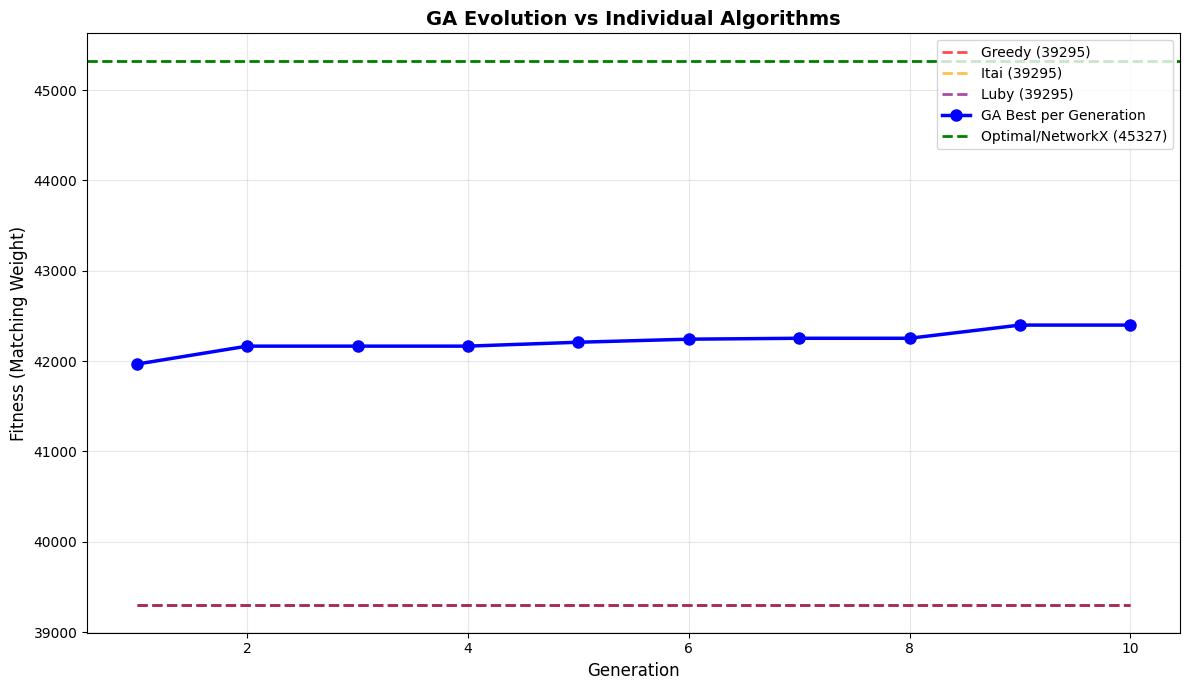

Fitness per generation:
Gen   GA           Greedy       Itai         Luby         Optimal     
-----------------------------------------------------------------
1     41967.0      39295.0      39295.0      39295.0      45327.0     
2     42166.0      39295.0      39295.0      39295.0      45327.0     
3     42166.0      39295.0      39295.0      39295.0      45327.0     
4     42166.0      39295.0      39295.0      39295.0      45327.0     
5     42209.0      39295.0      39295.0      39295.0      45327.0     
6     42243.0      39295.0      39295.0      39295.0      45327.0     
7     42253.0      39295.0      39295.0      39295.0      45327.0     
8     42253.0      39295.0      39295.0      39295.0      45327.0     
9     42399.0      39295.0      39295.0      39295.0      45327.0     
10    42399.0      39295.0      39295.0      39295.0      45327.0     

Algorithm Comparison:
  Greedy:        39295.0
  Itai:          39295.0
  Luby:          39295.0
  GA best:       42399.0
  Opti

In [10]:
# Plot fitness history with all three algorithm baselines
history = result['fitness_history']
generations_list = list(range(1, len(history) + 1))

greedy_line = [result['greedy_baseline']] * len(history)
itai_line = [result['itai_baseline']] * len(history)
luby_line = [result['luby_baseline']] * len(history)

plt.figure(figsize=(12, 7))

# Plot individual algorithms as dashed lines (baselines)
if result['greedy_baseline'] > 0:
    plt.plot(generations_list, greedy_line, 'r--', linewidth=2, label=f"Greedy ({result['greedy_baseline']:.0f})", alpha=0.7)
if result['itai_baseline'] > 0:
    plt.plot(generations_list, itai_line, 'orange', linestyle='--', linewidth=2, label=f"Itai ({result['itai_baseline']:.0f})", alpha=0.7)
if result['luby_baseline'] > 0:
    plt.plot(generations_list, luby_line, 'purple', linestyle='--', linewidth=2, label=f"Luby ({result['luby_baseline']:.0f})", alpha=0.7)

# Plot GA evolution as solid line
plt.plot(generations_list, history, 'b-', linewidth=2.5, markersize=8, marker='o', label='GA Best per Generation')

# Optimal baseline
plt.axhline(y=result['optimal_weight'], color='g', linestyle='--', linewidth=2, label=f"Optimal/NetworkX ({result['optimal_weight']:.0f})")

plt.xlabel('Generation', fontsize=12)
plt.ylabel('Fitness (Matching Weight)', fontsize=12)
plt.title('GA Evolution vs Individual Algorithms', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='best')
plt.tight_layout()
plt.show()

# Print comparison table
time_per_gen = result['ga_time_per_generation']

print("Fitness per generation:")
print(f"{'Gen':<5} {'GA':<12} {'Greedy':<12} {'Itai':<12} {'Luby':<12} {'Optimal':<12}")
print("-" * 65)
for gen, ga_fit in enumerate(history, 1):
    print(f"{gen:<5} {ga_fit:<12.1f} {result['greedy_baseline']:<12.1f} {result['itai_baseline']:<12.1f} {result['luby_baseline']:<12.1f} {result['optimal_weight']:<12.1f}")

print()
print("Algorithm Comparison:")
print(f"  Greedy:        {result['greedy_baseline']:.1f}")
print(f"  Itai:          {result['itai_baseline']:.1f}")
print(f"  Luby:          {result['luby_baseline']:.1f}")
print(f"  GA best:       {result['best_fitness']:.1f}")
print(f"  Optimal/NX:    {result['optimal_weight']:.1f}")
print()
print("GA vs Individual Algorithms:")
if result['greedy_baseline'] > 0:
    improvement = (result['best_fitness'] - result['greedy_baseline']) / result['greedy_baseline'] * 100
    print(f"  vs Greedy:     {improvement:+.1f}%")
if result['itai_baseline'] > 0:
    improvement = (result['best_fitness'] - result['itai_baseline']) / result['itai_baseline'] * 100
    print(f"  vs Itai:       {improvement:+.1f}%")
if result['luby_baseline'] > 0:
    improvement = (result['best_fitness'] - result['luby_baseline']) / result['luby_baseline'] * 100
    print(f"  vs Luby:       {improvement:+.1f}%")
print()

## Test 3: Compare All 1K Graphs

In [ ]:
# Test on all large 1K graphs
graph_fixtures_1k = [
    ("CLUSTERED_GRAPH_1K", CLUSTERED_GRAPH_1K),
    ("RANDOM_DENSE_GRAPH_1K", RANDOM_DENSE_GRAPH_1K),
    ("SCALE_FREE_GRAPH_1K", SCALE_FREE_GRAPH_1K),
    ("BIPARTITE_GRAPH_1K", BIPARTITE_GRAPH_1K),
]

results_1k = []

print("Running GA on all 1K graphs (this may take 1-2 minutes)...\n")
for graph_name, fixture in graph_fixtures_1k:
    print(f"Processing {graph_name}...")
    graph = fixture_to_graph(fixture)
    # Use smaller population/generations for 1K graphs (to keep time reasonable)
    result = run_ga_experiment(graph, fixture, graph_name, population_size=8, generations=3, mutation_rate=0.12)
    results_1k.append(result)
    print(f"  ✓ Best={result['best_fitness']:8.2f}, Optimal={result['optimal_weight']:8.2f}, Gap={result['gap_from_optimal']:+7.1f}%, Time={result['ga_total_time']:.2f}s\n")

print()

## Test 4: 1K Graphs Comparison Visualization

In [ ]:
# Compare results across 1K graphs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Best vs Optimal fitness
graph_names = [r['graph_name'] for r in results_1k]
best_fits = [r['best_fitness'] for r in results_1k]
optimal_fits = [r['optimal_weight'] for r in results_1k]

x = np.arange(len(graph_names))
width = 0.35

axes[0].bar(x - width/2, best_fits, width, label='GA Best', alpha=0.8)
axes[0].bar(x + width/2, optimal_fits, width, label='Optimal (NetworkX)', alpha=0.8)
axes[0].set_xlabel('Graph Type', fontsize=11)
axes[0].set_ylabel('Fitness', fontsize=11)
axes[0].set_title('GA vs Optimal Baseline (1K Graphs)', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([name.replace('_GRAPH_1K', '') for name in graph_names], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Gap from optimal percentage
gaps = [r['gap_from_optimal'] for r in results_1k]
colors = ['green' if gap < 5 else 'orange' if gap < 10 else 'red' for gap in gaps]

axes[1].bar([name.replace('_GRAPH_1K', '') for name in graph_names], gaps, color=colors, alpha=0.7)
axes[1].set_xlabel('Graph Type', fontsize=11)
axes[1].set_ylabel('Gap from Optimal (%)', fontsize=11)
axes[1].set_title('GA Solution Quality vs Optimal (1K Graphs)', fontsize=12, fontweight='bold')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='y')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Test 5: Small Graphs Comparison

In [ ]:
# Test on small graphs for baseline comparison
graph_fixtures_small = [
    ("GRID_4x4", GRID_4x4),
    ("K5_CLUSTERS", K5_CLUSTERS),
    ("STAR_WITH_TAIL", STAR_WITH_TAIL),
]

results_small = []

print("Running GA on small graphs for comparison...\n")
for graph_name, fixture in graph_fixtures_small:
    print(f"Processing {graph_name}...")
    graph = fixture_to_graph(fixture)
    result = run_ga_experiment(graph, fixture, graph_name, population_size=10, generations=8, mutation_rate=0.15)
    results_small.append(result)
    print(f"  ✓ Best={result['best_fitness']:8.2f}, Optimal={result['optimal_weight']:8.2f}, Gap={result['gap_from_optimal']:+7.1f}%\n")

print()

## Test 6: Convergence Analysis on 1K Graph

In [12]:
# Extended convergence test on clustered graph
print("Running extended convergence analysis (10 generations on 1K graph)...")
graph = fixture_to_graph(CLUSTERED_GRAPH_1K)
result = run_ga_experiment(graph, CLUSTERED_GRAPH_1K, "CLUSTERED_1K_EXTENDED", 
                           population_size=10, generations=10, mutation_rate=0.15)

history = result['fitness_history']
generations_list = list(range(1, len(history) + 1))

# Calculate convergence metrics
improvements = [history[i] - history[i-1] if i > 0 else 0 for i in range(len(history))]
converged_gen = next((i for i, imp in enumerate(improvements[1:], 1) if imp < 0.01), len(improvements))

print(f"\nConvergence Analysis ({len(history)} generations):")
print(f"  Best fitness: {history[-1]:.2f}")
print(f"  Converged at generation: {converged_gen}")
print(f"  Total improvement: {history[-1] - history[0]:.2f}")
print(f"  Total time: {result['ga_total_time']:.2f}s")
print()

Running extended convergence analysis (10 generations on 1K graph)...
  Getting algorithm baselines... ✓
  Running GA optimization... ✓

Convergence Analysis (10 generations):
  Best fitness: 42497.00
  Converged at generation: 4
  Total improvement: 404.00
  Total time: 320.87s



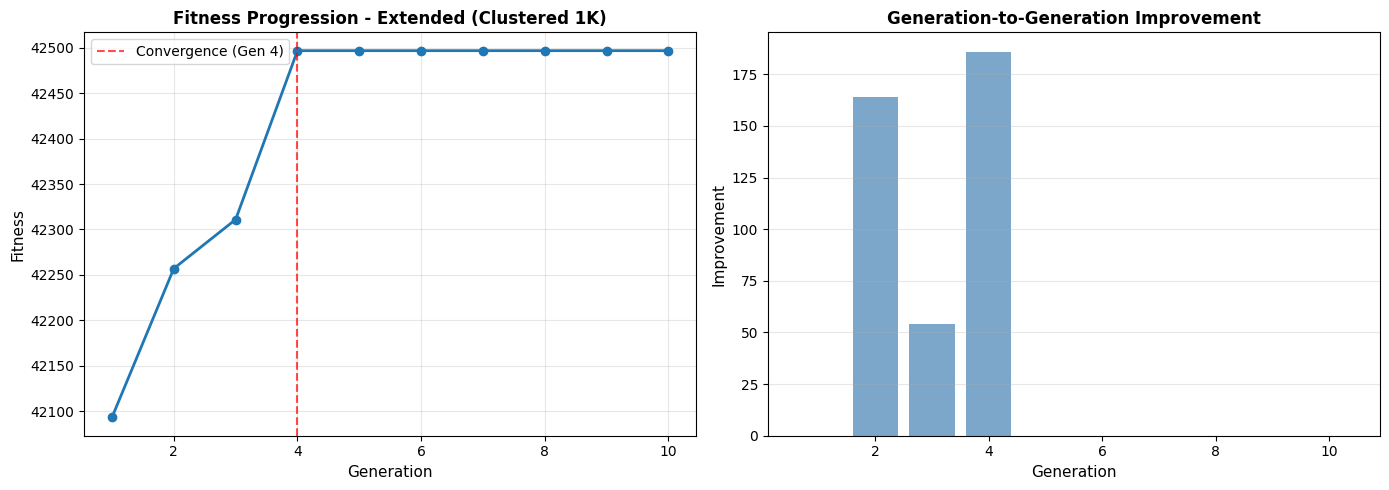

In [13]:
# Plot convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fitness history
axes[0].plot(generations_list, history, marker='o', linewidth=2, markersize=6)
axes[0].axvline(x=converged_gen, color='red', linestyle='--', alpha=0.7, label=f'Convergence (Gen {converged_gen})')
axes[0].set_xlabel('Generation', fontsize=11)
axes[0].set_ylabel('Fitness', fontsize=11)
axes[0].set_title('Fitness Progression - Extended (Clustered 1K)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Improvements per generation
axes[1].bar(generations_list, improvements, alpha=0.7, color='steelblue')
axes[1].set_xlabel('Generation', fontsize=11)
axes[1].set_ylabel('Improvement', fontsize=11)
axes[1].set_title('Generation-to-Generation Improvement', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()